# 3. Image Preprocessing and Visualization utilities
Before passing images into deep learning models, we must preprocess them. Furthermore, we need a high-quality interactive visualization layer.

In this notebook, we:
1. Load images using our `utils.load_image` function.
2. Examine image dimensions, resizing, padding, and normalizations.
3. Test our dynamic, clickable bounding box rendering tool (`utils.generate_interactive_html`).



In [1]:
import os
import sys
from PIL import Image

sys.path.append(os.path.abspath("."))

from fashion_detector.utils import (
    load_image,
    draw_bounding_boxes,
    generate_interactive_html,
)
from fashion_detector.models.base import Detection
from IPython.display import HTML

# Load image
img_path = "data/fashion_model_street.jpg"
image = load_image(img_path)
print(f"Successfully loaded image {img_path} with size: {image.size}")

[2026-07-20 22:14:35] [INFO] [fashion_detector:utils.py:31] - Loading image from local path: data/fashion_model_street.jpg
Successfully loaded image data/fashion_model_street.jpg with size: (800, 1107)


## Creating Bounding Box Proposals for Testing
Let's create a few dummy detections to test both static drawing and our premium, clickable interactive HTML interface.



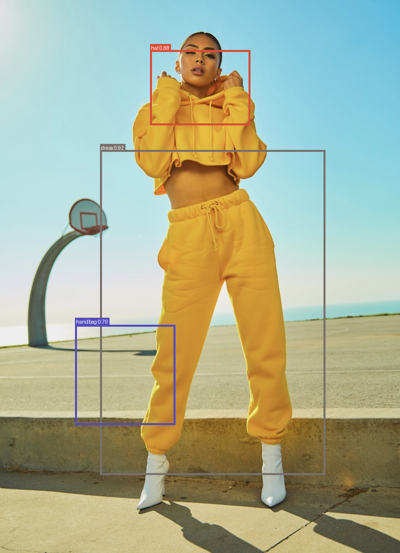

In [2]:
# Dummy detections for testing
detections = [
    Detection(box=[200.0, 300.0, 650.0, 950.0], label="dress", score=0.92),
    Detection(box=[300.0, 100.0, 500.0, 250.0], label="hat", score=0.88),
    Detection(box=[150.0, 650.0, 350.0, 850.0], label="handbag", score=0.79),
]

# Render static image annotated with Pillow
annotated_img = draw_bounding_boxes(image, detections)
display(
    annotated_img.resize((400, int(400 * annotated_img.height / annotated_img.width)))
)

## Clickable, Interactive HTML Visualization
Run the cell below to test the interactive widget. You can hover over boxes for tooltips, and click on them to populate item information in the panel below!




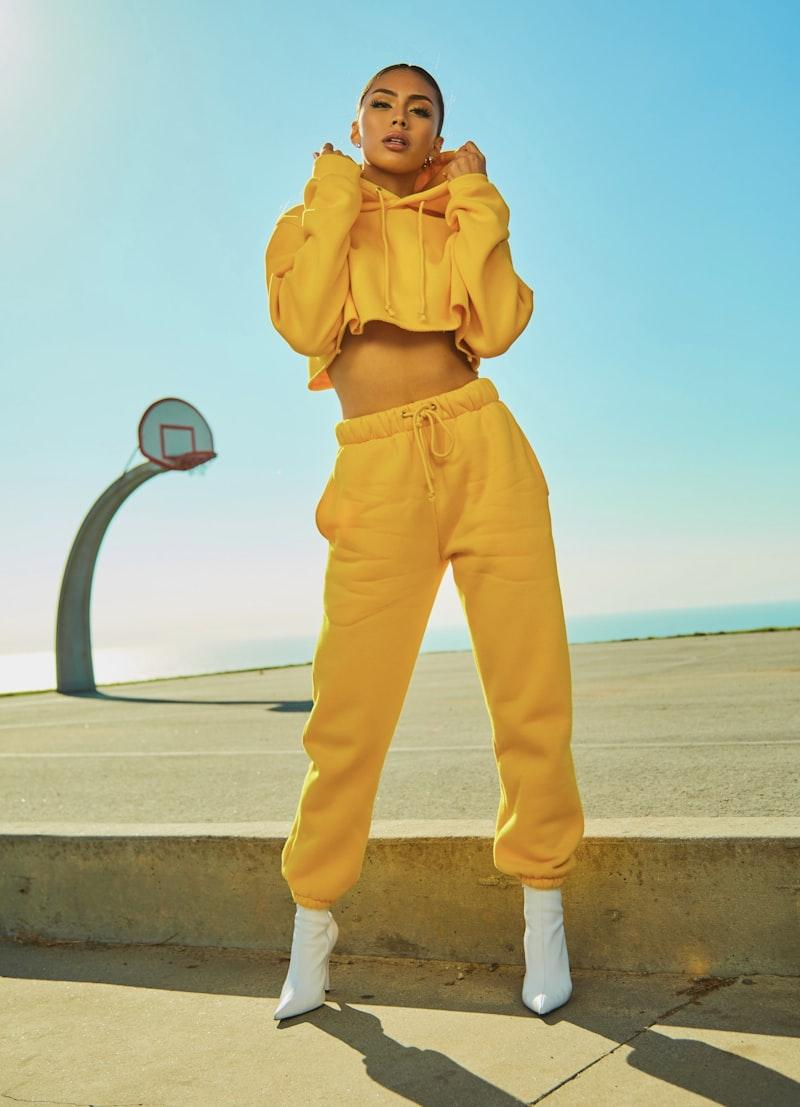

In [3]:
# Render interactive HTML overlay
html_str = generate_interactive_html(
    image, detections, title="Interactive Proposal Test"
)
HTML(html_str)